# Embeddings and Chunking with LlamaIndex and Gemini

In this notebook, we explore different chunking techniques and embedding models in LlamaIndex while using Google's Gemini for our language model. We'll learn how different chunking strategies affect retrieval performance and how to use various embedding models.

## Setup and Installation

First, let's install the necessary packages:

In [1]:
!pip install -q llama-index
!pip install -q llama-index-embeddings-huggingface
#!pip install -q llama-index-llms-gemini
!pip install -U llama-index llama-index-llms-google-genai
#pip install -q llama-index-embeddings-openai
!pip install -q llama-index-vector-stores-chroma
!pip install -q sentence-transformers
!pip install -q chromadb
!pip install -q python-dotenv
!pip install opentelemetry-sdk

/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.7

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.
/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.7

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.
/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.7

Note: See 'pyenv help global' 

Now let's set up our environment:

In [2]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [3]:
# Load Gemini API key from .env (gitignored); copy .env.example to .env and add your key
from dotenv import load_dotenv
load_dotenv()
if not os.environ.get("GOOGLE_API_KEY"):
    raise ValueError("Set GOOGLE_API_KEY in .env or environment")

## 1. Loading Sample Documents

We'll create a small sample of documents to work with. First, let's create a directory and some sample files:

In [4]:
!mkdir -p sample_docs

/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env


In [5]:
# Let's create some example documents
with open("sample_docs/ai_history.txt", "w") as f:
    f.write("""Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These models are trained on vast amounts of text data and can generate human-like responses.""")

with open("sample_docs/neural_networks.txt", "w") as f:
    f.write("""Neural networks are computing systems inspired by biological neural networks.
The perceptron, developed by Frank Rosenblatt in 1958, was one of the earliest neural network models.
Modern neural networks consist of layers of interconnected nodes or "neurons."
Each connection can transmit a signal from one neuron to another.
The receiving neuron processes the signal and signals downstream neurons connected to it.
Deep neural networks contain multiple hidden layers between input and output layers.
Convolutional Neural Networks (CNNs) revolutionized image processing.
Recurrent Neural Networks (RNNs) and transformers handle sequential data like text or time series.""")

with open("sample_docs/embeddings.txt", "w") as f:
    f.write("""Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techniques include Word2Vec, GloVe, and FastText.
Sentence embeddings capture meaning at the sentence level rather than individual words.
Models like Universal Sentence Encoder and SBERT create powerful sentence embeddings.
Document embeddings represent entire documents as fixed-length vectors.
Embeddings enable semantic search by finding documents with similar meaning, not just keyword matches.
They also power recommendation systems, clustering, and classification tasks.
Recent models like OpenAI's text-embedding-ada and Cohere's embedding models offer state-of-the-art performance.""")

Now let's load these documents using LlamaIndex:

In [6]:
from llama_index.core import SimpleDirectoryReader

# Load documents
documents = SimpleDirectoryReader("sample_docs").load_data()
print(f"Loaded {len(documents)} documents.")

# Display document contents
for i, doc in enumerate(documents):
    print(f"\n--- Document {i+1}: {doc.metadata['file_name']} ---")
    print(doc.text[:200] + "...")  # Show first 200 chars

Loaded 3 documents.

--- Document 1: ai_history.txt ---
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods ...

--- Document 2: embeddings.txt ---
Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techni...

--- Document 3: neural_networks.txt ---
Neural networks are computing systems inspired by biological neural networks.
The perceptron, developed by Frank Rosenblatt in 1958, was one of the earliest neural network models.
Modern neural networ...


## 2. Exploring Different Chunking Techniques

Chunking is a critical preprocessing step for using documents with LLMs. Let's explore different chunking strategies:



### 2.1 Fixed-Length Chunking

The simplest approach is to divide text into chunks of a fixed size:

In [7]:
from llama_index.core.node_parser import SentenceSplitter

# Fixed-length chunking with no overlap
splitter_fixed = SentenceSplitter(chunk_size=100, chunk_overlap=0)
chunks_fixed = splitter_fixed.get_nodes_from_documents(documents)
print(f"Total Fixed-Length Chunks Created: {len(chunks_fixed)}")

# Display a sample chunk
print(f"\nSample fixed-length chunk:")
print(chunks_fixed[0].text)


print(f"\nSample fixed-length chunk:")
print(chunks_fixed[1].text)
print(f"\nSample fixed-length chunk:")
print(chunks_fixed[2].text)


Total Fixed-Length Chunks Created: 6

Sample fixed-length chunk:
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.

Sample fixed-length chunk:
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These models are trained on vast amounts of text data and can generate human-like responses.

Sample fixed-length chunk:
Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techniques include Word2Vec, GloVe, 

### 2.2 Overlapping Chunks

Adding overlap between chunks helps maintain context across chunk boundaries:

In [8]:
# Chunking with overlap
splitter_overlap = SentenceSplitter(chunk_size=100, chunk_overlap=20)
chunks_overlap = splitter_overlap.get_nodes_from_documents(documents)
print(f"Total Overlapping Chunks Created: {len(chunks_overlap)}")

# Display a sample chunk with its neighbor to see overlap
print(f"\nOverlap Example:")
print(f"Chunk 1: {chunks_overlap[0].text}")

print(f"\nOverlap Example:")
print(f"Chunk 2: {chunks_overlap[1].text}")

Total Overlapping Chunks Created: 7

Overlap Example:
Chunk 1: Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.

Overlap Example:
Chunk 2: In the 1980s, expert systems became popular but faced limitations.
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.


### 2.3 Semantic Chunking

Semantic chunking splits text based on meaning rather than just token count:

In [9]:
from llama_index.core.node_parser import SemanticSplitterNodeParser
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize embedding model for semantic splitting
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create semantic chunker
semantic_splitter = SemanticSplitterNodeParser(embed_model=embed_model)
chunks_semantic = semantic_splitter.get_nodes_from_documents(documents)
print(f"Total Semantic Chunks Created: {len(chunks_semantic)}")

# Display a sample semantic chunk
print(f"\nSample semantic chunk:")
print(chunks_semantic[0].text)
print ("--------------------")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-03 14:12:50,465 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2026-03-03 14:12:50,566 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:50,579 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-03 14:12:50,677 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:50,704 - 

Total Semantic Chunks Created: 6

Sample semantic chunk:
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.

--------------------


In [10]:
print(f"\nSample semantic chunk:")
print(chunks_semantic[0].text)
print ("--------------------")

print(f"\nSample semantic chunk:")
print(chunks_semantic[1].text)
print ("--------------------")

print(f"\nSample semantic chunk:")
print(chunks_semantic[2].text)
print ("--------------------")

print(f"\nSample semantic chunk:")
print(chunks_semantic[3].text)
print ("--------------------")


Sample semantic chunk:
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.

--------------------

Sample semantic chunk:
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These models are trained on vast amounts of text data and can generate human-like responses.
--------------------

Sample semantic chunk:
Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techniques include Word2Vec, GloVe, and Fa

### 2.4 Comparison of Chunking Strategies

Let's compare our chunking strategies:

,Strategy,Number of Chunks,Average Chunk Length
0,Fixed-Length,6,349.333333
1,Overlapping,7,332.000000
2,Semantic,6,349.833333


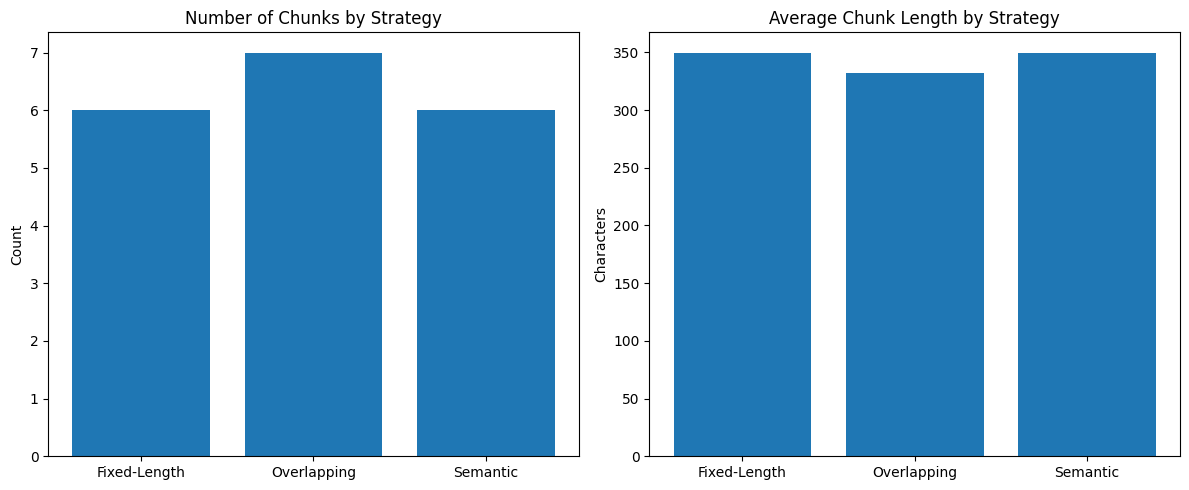

In [11]:
chunking_comparison = pd.DataFrame({
    'Strategy': ['Fixed-Length', 'Overlapping', 'Semantic'],
    'Number of Chunks': [len(chunks_fixed), len(chunks_overlap), len(chunks_semantic)],
    'Average Chunk Length': [
        sum(len(chunk.text) for chunk in chunks_fixed) / len(chunks_fixed),
        sum(len(chunk.text) for chunk in chunks_overlap) / len(chunks_overlap),
        sum(len(chunk.text) for chunk in chunks_semantic) / len(chunks_semantic)
    ]
})

display(chunking_comparison)

# Visualize the comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(chunking_comparison['Strategy'], chunking_comparison['Number of Chunks'])
plt.title('Number of Chunks by Strategy')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.bar(chunking_comparison['Strategy'], chunking_comparison['Average Chunk Length'])
plt.title('Average Chunk Length by Strategy')
plt.ylabel('Characters')

plt.tight_layout()
plt.show()

## 3. Exploring Different Embedding Models

Embeddings convert text into numerical vectors. Let's explore different embedding models:

### 3.1 Hugging Face Embeddings

In [12]:
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

# Initialize a list to store results
embedding_results = []

# Test different HuggingFace embedding models
hf_models = [
    "sentence-transformers/all-MiniLM-L6-v2",  # Small, fast model (384 dimensions)
    "sentence-transformers/all-mpnet-base-v2",  # More powerful (768 dimensions)
]

for model_name in hf_models:
    start_time = time.time()

    embed_model = HuggingFaceEmbedding(model_name=model_name)

    # Generate an embedding for a test sentence
    test_text = "Embeddings are numerical representations of text in vector space."
    embedding = embed_model.get_text_embedding(test_text)

    end_time = time.time()

    embedding_results.append({
        'Model': model_name,
        'Dimensions': len(embedding),
        'Generation Time (s)': end_time - start_time
    })

# Display results
embedding_df = pd.DataFrame(embedding_results)
display(embedding_df)

2026-03-03 14:12:52,679 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2026-03-03 14:12:52,719 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:52,732 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-03 14:12:52,774 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:52,787 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-03 14:12:52,945 - INFO - HTTP Request: HEAD https://huggingface.co/sent

,Model,Dimensions,Generation Time (s)
0,sentence-transformers/all-MiniLM-L6-v2,384,1.88299
1,sentence-transformers/all-mpnet-base-v2,768,1.81499


### 3.3 Visualizing Embedding Similarity

Let's visualize how different texts are related in embedding space:

2026-03-03 14:12:56,386 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2026-03-03 14:12:56,456 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:56,467 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-03 14:12:56,519 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:56,568 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-03 14:12:56,636 - INFO - HTTP Request: HEAD https://huggingface.co/sent

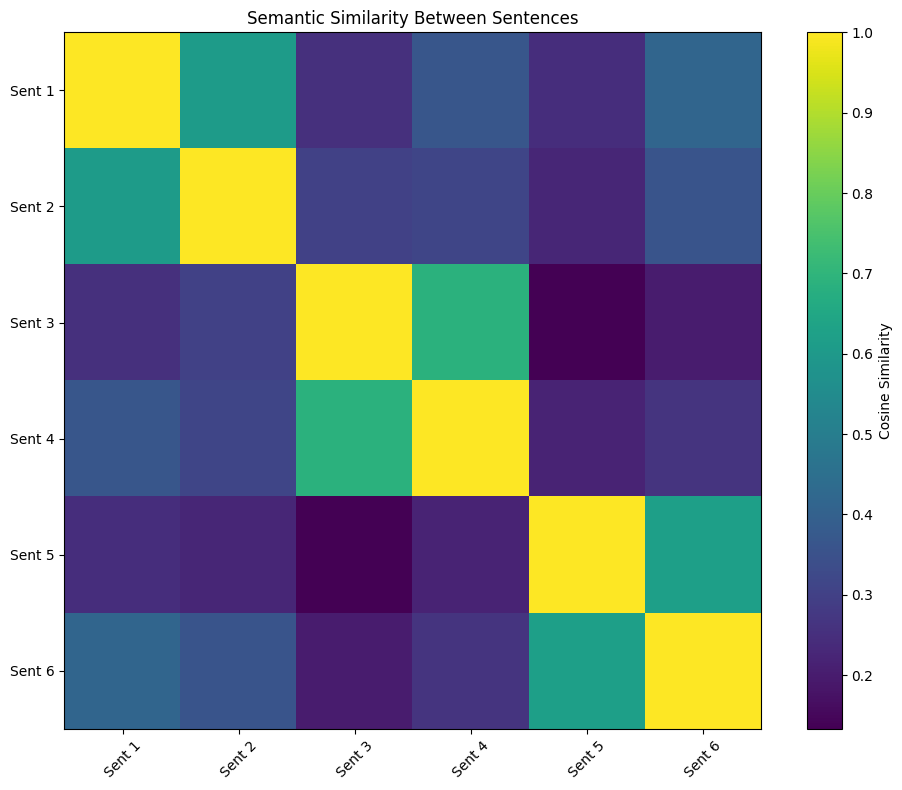

Sentence 1: Neural networks are a powerful machine learning technique.
Sentence 2: Deep learning models have many layers of neurons.
Sentence 3: Embeddings represent words or sentences as vectors.
Sentence 4: Vector representations help computers understand semantics.
Sentence 5: The history of AI begins in the 1950s.
Sentence 6: Artificial intelligence research has evolved over decades.


In [13]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define some test sentences
test_sentences = [
    "Neural networks are a powerful machine learning technique.",
    "Deep learning models have many layers of neurons.",
    "Embeddings represent words or sentences as vectors.",
    "Vector representations help computers understand semantics.",
    "The history of AI begins in the 1950s.",
    "Artificial intelligence research has evolved over decades."
]

# Create embeddings for each sentence
embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")
embeddings = [embed_model.get_text_embedding(sent) for sent in test_sentences]

# Calculate similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Visualize the similarity matrix
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix, cmap='viridis')
plt.colorbar(label='Cosine Similarity')
plt.xticks(np.arange(len(test_sentences)), [f"Sent {i+1}" for i in range(len(test_sentences))], rotation=45)
plt.yticks(np.arange(len(test_sentences)), [f"Sent {i+1}" for i in range(len(test_sentences))])
plt.title('Semantic Similarity Between Sentences')
plt.tight_layout()
plt.show()

# Print the sentences for reference
for i, sent in enumerate(test_sentences):
    print(f"Sentence {i+1}: {sent}")

## 4. Building a Vector Store with LlamaIndex

Now, let's combine what we've learned to build a vector database:

In [14]:
# Install ChromaDB telemetry dependency for this kernel's Python (run once)
import sys, subprocess, site
subprocess.check_call([sys.executable, "-m", "pip", "install", "opentelemetry-sdk", "-q"])
# Ensure user site-packages is on path so the new package is visible this run
for p in site.getsitepackages() + [site.getusersitepackages()]:
    if p and p not in sys.path:
        sys.path.insert(0, p)

from llama_index.core import VectorStoreIndex, StorageContext
from llama_index.vector_stores.chroma import ChromaVectorStore
import chromadb

# Initialize a Chroma client
chroma_client = chromadb.Client()
chroma_collection = chroma_client.get_or_create_collection("semantic_search_demo")

# Create vector store
vector_store = ChromaVectorStore(chroma_collection=chroma_collection)
storage_context = StorageContext.from_defaults(vector_store=vector_store)


embed_model = HuggingFaceEmbedding(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Create index
index = VectorStoreIndex.from_documents(
    documents,
    storage_context=storage_context,
    embed_model=embed_model
)

print("Vector store created successfully!")


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
2026-03-03 14:12:58,621 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
2026-03-03 14:12:58,706 - INFO - Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
2026-03-03 14:12:58,826 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:58,889 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-03 14:12:58,960 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-03 14:12:59,008 - INFO - HTTP Request: HEAD h

Vector store created successfully!



## 5. Querying with Gemini

Finally, let's use Gemini to query our vector database:

In [15]:
import nest_asyncio
nest_asyncio.apply()
from llama_index.llms.google_genai import GoogleGenAI

#from llama_index.llms.gemini import Gemini

# Initialize Gemini LLM
llm = GoogleGenAI(model="models/gemini-2.5-flash")

# Set up query engine with our custom components
query_engine = index.as_query_engine(
    llm=llm,
    similarity_top_k=2  # Retrieve top 2 most similar chunks
)

# Function to query and display results
def run_query(query_text):
    print(f"Query: {query_text}")
    print("-" * 50)

    # Get response
    response = query_engine.query(query_text)

    print("Response:")
    display(Markdown(response.response))

    print("\nSource Nodes:")
    for i, node in enumerate(response.source_nodes):
        print(f"\nSource {i+1} (Score: {node.score:.4f}):")
        print("-" * 40)
        print(node.text)

    return response

# Try different queries
queries = [
    "How did neural networks develop over time?",
    "What are embeddings and how are they used?",
    "Explain the history of artificial intelligence."
]

# Run each query
for query in queries:
    run_query(query)
    print("\n" + "="*80 + "\n")

2026-03-03 14:13:00,664 - INFO - HTTP Request: GET https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash "HTTP/1.1 200 OK"
2026-03-03 14:13:00,682 - INFO - AFC is enabled with max remote calls: 10.


Query: How did neural networks develop over time?
--------------------------------------------------


2026-03-03 14:13:02,578 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


Response:


Neural networks began with early models such as the perceptron, developed in 1958. Modern iterations are characterized by layers of interconnected nodes, where signals are transmitted and processed. Deep neural networks distinguish themselves by incorporating multiple hidden layers between their input and output layers. Over time, specialized architectures emerged, including Convolutional Neural Networks (CNNs) for image processing and Recurrent Neural Networks (RNNs) and transformers for handling sequential data. The deep learning revolution, starting around 2012, brought significant advancements, particularly in computer vision. Currently, large language models exemplify the forefront of neural network capabilities.

...


Source Nodes:

Source 1 (Score: 0.3964):
----------------------------------------
Embeddings are dense vector representations of data in a continuous vector space.
Word embeddings map words to vectors where similar words are positioned closer together.
Popular word embedding techniques include Word2Vec, GloVe, and FastText.
Sentence embeddings capture meaning at the sentence level rather than individual words.
Models like Universal Sentence Encoder and SBERT create powerful sentence embeddings.
Document embeddings represent entire documents as fixed-length vectors.
Embeddings enable semantic search by finding documents with similar meaning, not just keyword matches.
They also power recommendation systems, clustering, and classification tasks.
Recent models like OpenAI's text-embedding-ada and Cohere's embedding models offer state-of-the-art performance.

Source 2 (Score: 0.2263):
----------------------------------------
Neural networks are computing systems inspired by biological neur

2026-03-03 14:13:06,291 - INFO - HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent "HTTP/1.1 200 OK"


Response:


Artificial Intelligence (AI) traces its origins to the 1950s, with the term itself being introduced by John McCarthy in 1956 at the Dartmouth Conference. Initial research in AI concentrated on symbolic methods and systems based on rules. The 1980s saw the rise in popularity of expert systems, though these eventually encountered limitations.

A transition towards machine learning approaches characterized the 1990s and early 2000s. A significant turning point, the deep learning revolution, commenced around 2012, marked by groundbreaking achievements in computer vision. Currently, advanced AI capabilities are exemplified by large language models such as GPT, LLaMA, and Gemini, which are trained on extensive text datasets to produce responses resembling human communication.


Source Nodes:

Source 1 (Score: 0.4796):
----------------------------------------
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods and rule-based systems.
In the 1980s, expert systems became popular but faced limitations.
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models like GPT, LLaMA, and Gemini represent cutting-edge AI capabilities.
These models are trained on vast amounts of text data and can generate human-like responses.

Source 2 (Score: 0.2977):
----------------------------------------
Neural networks are computing systems inspired by biological neural networks.
The perceptron, developed by Frank Rosenblatt in 1958, was one of the earliest neural network models.
Modern neural networ

## 6. Interactive Experiments

This section provides instructions and examples for hands-on experimentation with chunking and embedding techniques. Try these experiments to deepen your understanding.

### Experiment 1: Testing Different Chunking Parameters

Try modifying the chunking parameters to see how they affect the results:

In [16]:
# EXPERIMENT: Test different chunk sizes and overlaps
# Try these combinations and compare the results:
# 1. Small chunks (100 tokens) with no overlap
# 2. Medium chunks (300 tokens) with small overlap (30 tokens)
# 3. Large chunks (500 tokens) with larger overlap (100 tokens)

# Example code to experiment with:
from llama_index.core.node_parser import SentenceSplitter

# Example 1: Small chunks, no overlap
splitter_small = SentenceSplitter(chunk_size=100, chunk_overlap=0)
chunks_small = splitter_small.get_nodes_from_documents(documents)
print(f"Small chunks: Created {len(chunks_small)} chunks")

# Example 2: Medium chunks with overlap
splitter_medium = SentenceSplitter(chunk_size=300, chunk_overlap=30)
chunks_medium = splitter_medium.get_nodes_from_documents(documents)
print(f"Medium chunks: Created {len(chunks_medium)} chunks")

# Example 3: Large chunks with larger overlap
splitter_large = SentenceSplitter(chunk_size=500, chunk_overlap=100)
chunks_large = splitter_large.get_nodes_from_documents(documents)
print(f"Large chunks: Created {len(chunks_large)} chunks")

# To inspect chunks, print a few examples:
def inspect_chunks(chunks, name):
    print(f"\n--- First chunk from {name} ---")
    print(chunks[0].text[:200] + "...")  # Show first 200 chars of first chunk
    print(f"Character count: {len(chunks[0].text)}")
    if len(chunks) > 1:
        print(f"\n--- Second chunk from {name} ---")
        print(chunks[1].text[:200] + "...")  # Show first 200 chars of second chunk
        print(f"Character count: {len(chunks[1].text)}")

# Inspect samples from each chunking strategy
inspect_chunks(chunks_small, "small chunks")
inspect_chunks(chunks_medium, "medium chunks")
inspect_chunks(chunks_large, "large chunks")

Small chunks: Created 6 chunks
Medium chunks: Created 3 chunks
Large chunks: Created 3 chunks

--- First chunk from small chunks ---
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods ...
Character count: 290

--- Second chunk from small chunks ---
The 1990s and early 2000s saw a shift towards machine learning approaches.
The deep learning revolution began around 2012 with breakthrough results in computer vision.
Today, large language models lik...
Character count: 357

--- First chunk from medium chunks ---
Artificial Intelligence (AI) has a rich history dating back to the 1950s.
The term was first coined by John McCarthy in 1956 at the Dartmouth Conference.
Early AI research focused on symbolic methods ...
Character count: 648

--- Second chunk from medium chunks ---
Embeddings are dense vector representations of data in a continuous vec